<a href="https://colab.research.google.com/github/elliotdecker/Astron-98-Final-Project---Elliot-Decker/blob/main/Week3_RotationCurves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rotation Curve Buffet

*class*: Astron 7B

*Week*: Week 3 (2/2/26)

---

In this notebook, we're going to use a really useful library called ``gala`` [documentation](https://gala.adrian.pw/en/latest/#) to look at the theoretical rotation curve of a bunch of different galaxy models that I've put together.

**Instructions**: **You shouldn't need any coding skills** to use this notebook:

- In cells which **do NOT have code**, just read the text / instructions I have left you there.
- In cells which **do have code**, I may ask you to fill in the values of some variables so that you can interact with the demo. If I do so, you'll see
  ```python
  # !!!!!!!!!!!!!!!!!!!!!!!!!!! #
  # FILL IN THE BLANK:          #
  # !!!!!!!!!!!!!!!!!!!!!!!!!!! #
  # ... some text about what this is...
  variable = value
  ```
- To run a cell, you can press the "run" button on the task bar or use CTRL+ENTER. If you want to re-run all of the cells, you can do that from the task bar.

## Learning Goals

By the end of this activity, you should be able to:

1. Explain what a galaxy rotation curve is and how it relates to mass distribution.
2. Predict how rotation curves behave for visible matter alone.
3. Explain why dark matter is required to explain observed flat rotation curves.
4. Interpret differences between model predictions and observations.

## Setup

First off, we're going to just need to download and install the library. Just go ahead and run the following cell and wait for the install to complete.

In [ ]:
! pip install gala

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 65.5 MB/s eta 0:00:00


## Model 1: A Galaxy Disk Alone

---

We begin with the simplest possible model of a galaxy: a system in which **all of the mass is contained in a stellar disk**.
This represents what we would infer if gravity were produced only by the visible stars and gas in the galaxy.

In this model:
- There is **no dark matter halo**
- There is **no bulge**
- The gravitational potential arises solely from the disk

To represent the disk, we use the **Miyamoto–Nagai potential**, a commonly used analytic model that approximates a flattened,
axisymmetric stellar disk. Although idealized, it captures the essential geometry of real galactic disks and allows us
to compute rotation curves analytically and efficiently.

Before proceeding, consider the following:

> **Prediction Checkpoint**
>
> If all of a galaxy’s mass is confined to a disk, how should the orbital speed of stars change as we move farther from the
> galactic center? Should the rotation curve rise, fall, or remain flat at large radii?

We now construct a Miyamoto–Nagai disk potential and examine its mass density distribution.


Text(0, 0.5, 'z [kpc]')

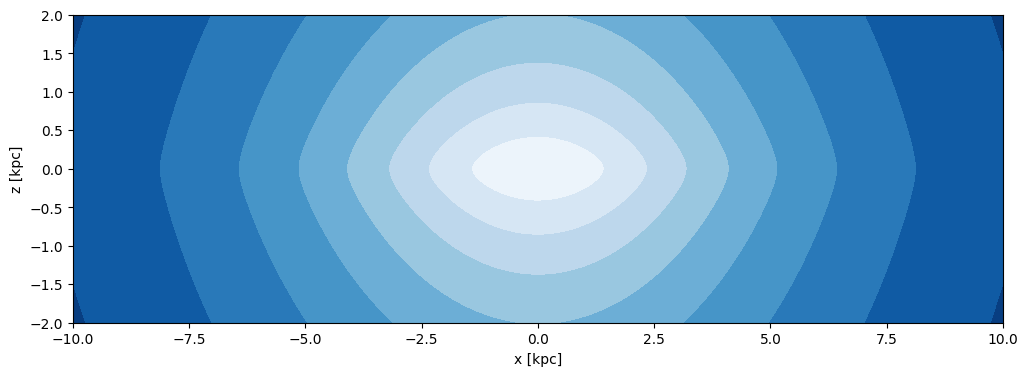

In [ ]:
import numpy as np
import astropy.units as u
import gala.potential as gp
from gala.units import galactic # (kpc, Myr, Msun, rad)
import matplotlib.pyplot as plt

# !!!!!!!!!!!!!!!!!!!!!!!!!!! #
# ### Fill In the Blank ###   #
# !!!!!!!!!!!!!!!!!!!!!!!!!!! #
disk_mass = 6e10  # Solar Masses
scale_length = 3.5 # kpc (horizontal spread)
scale_height = 0.2 # kpc (vertical thickness)
# !!!!!!!!!!!!!!!!!!!!!!!!!!! #

disk = gp.MiyamotoNagaiPotential(m=disk_mass * u.Msun,
                                 a=scale_length * u.kpc,
                                 b=scale_height * u.kpc,
                                 units=galactic)

# Create a figure.
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# 2. Visualize the Density in the x-z plane
# We define a grid of coordinates to evaluate the density
sz = np.linspace(-2, 2, 250) * u.kpc
sx = np.linspace(-10, 10, 250) * u.kpc
fig = disk.plot_contours((sx,1,sz),ax=ax)
ax.set_xlabel("x [kpc]")
ax.set_ylabel("z [kpc]")

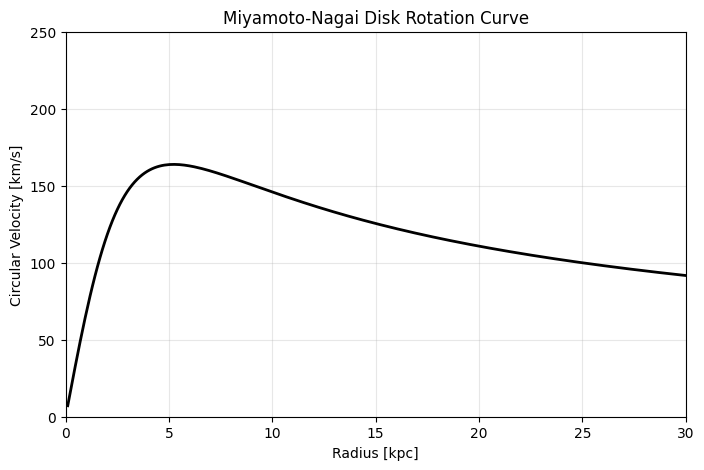

In [ ]:
# Compute the rotation curve.
import matplotlib.pyplot as plt

# 1. Define the radial range (from near the center to the outskirts)
r = np.linspace(0.1, 30, 250) * u.kpc

# 2. Create the position grid [x, y, z]
# We evaluate along the x-axis, so y=0 and z=0
pos = np.zeros((3, len(r))) * u.kpc
pos[0] = r

# 3. Calculate circular velocity
v_circ = disk.circular_velocity(pos)

# 4. Plotting
plt.figure(figsize=(8, 5))
plt.plot(r, v_circ.to(u.km/u.s), lw=2, color='black')

plt.title("Miyamoto-Nagai Disk Rotation Curve")
plt.xlabel(f"Radius [{r.unit}]")
plt.ylabel("Circular Velocity [km/s]")
plt.grid(True, alpha=0.3)
plt.xlim(0, 30)
plt.ylim(0, 250)
plt.show()

## Model 2: Galaxy Disk + Dark Matter Halo

---

The disk-only model represents what we would expect if gravity were produced solely by the visible matter in a galaxy.
However, real galaxies exhibit rotation curves that remain nearly flat at large radii—behavior that cannot be explained
by a disk alone.

To address this discrepancy, we now extend our model by adding a **dark matter halo** surrounding the galactic disk.
Unlike stars and gas, dark matter does not emit light, but its gravitational influence dominates the outer regions of galaxies.

We model the halo using the **Navarro–Frenk–White (NFW) profile**, a widely used density profile that emerges naturally
from cosmological simulations of structure formation in a cold dark matter universe. The NFW halo is roughly spherical
and extends far beyond the visible disk, providing additional mass at large radii. The density of the NFW profile is

$$
\rho(r) = \frac{\rho_0}{\xi(1+\xi)^2},\;\xi = r/r_s
$$

> This is a profile YOU SHOULD KNOW BY NAME. It is the most famous halo model in
> the field and it crops up just about everywhere.

In this model:
- The stellar disk is unchanged from Model 1
- A spherical dark matter halo is added
- The total gravitational potential is the **sum** of the disk and halo potentials

Before computing the rotation curve, consider:

> **Prediction Checkpoint**
>
> How should adding a massive, extended halo affect the rotation curve at large distances from the galactic center?
> Will the orbital speed decrease, remain constant, or increase compared to the disk-only case?

We now compute the combined gravitational potential and examine how the resulting rotation curve differs from the disk-only model.


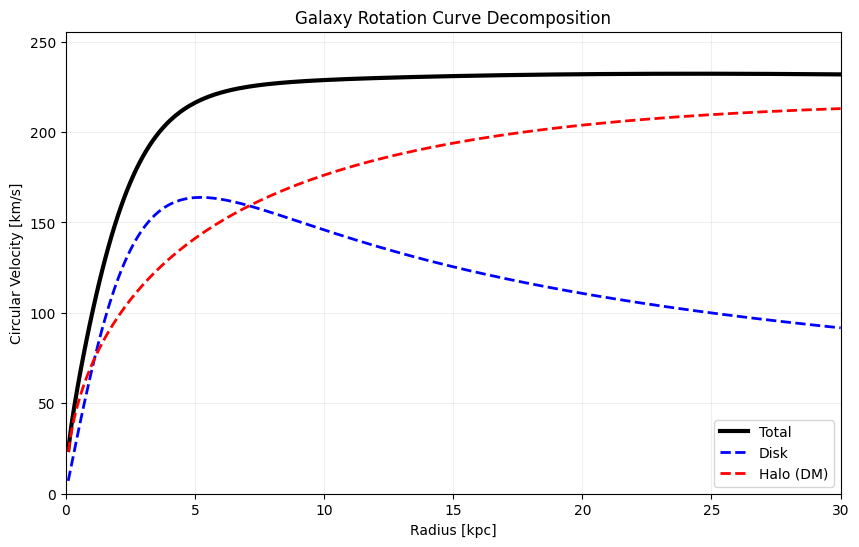

In [ ]:
# !!!!!!!!!!!!!!!!!!!!!!!!!!! #
# ### Fill In the Blank ###   #
# !!!!!!!!!!!!!!!!!!!!!!!!!!! #
disk_mass = 6e10  # Solar Masses
halo_mass = 1e12 # Solar masses
scale_length = 3.5 # kpc (horizontal spread)
scale_height = 0.2 # kpc (vertical thickness)
halo_scale_length = 20 # kpc
# !!!!!!!!!!!!!!!!!!!!!!!!!!! #
disk = gp.MiyamotoNagaiPotential(m=disk_mass * u.Msun,
                                 a=scale_length * u.kpc,
                                 b=scale_height * u.kpc,
                                 units=galactic)

halo = gp.NFWPotential(m=halo_mass * u.Msun,
                       r_s=halo_scale_length * u.kpc,
                       units=galactic)

# 2. Combine them into a single potential
# Gala makes this incredibly easy with the + operator
total_pot = disk + halo

# 3. Calculate velocities for components and total
v_disk = disk.circular_velocity(pos)
v_halo = halo.circular_velocity(pos)
v_total = total_pot.circular_velocity(pos)

# 4. Plotting the decomposition
plt.figure(figsize=(10, 6))

plt.plot(r, v_total.to(u.km/u.s), label='Total', lw=3, color='black')
plt.plot(r, v_disk.to(u.km/u.s), label='Disk', lw=2, linestyle='--', color='blue')
plt.plot(r, v_halo.to(u.km/u.s), label='Halo (DM)', lw=2, linestyle='--', color='red')

plt.title("Galaxy Rotation Curve Decomposition")
plt.xlabel("Radius [kpc]")
plt.ylabel("Circular Velocity [km/s]")
plt.legend()
plt.grid(True, alpha=0.2)
plt.xlim(0, 30)
plt.ylim(0, 1.1*np.amax(v_total.to_value("km/s")))
plt.show()

## What Did We Learn?

Based on the models you explored:

1. Why does the disk-only model fail to reproduce observed galaxy rotation curves?
2. What property of the dark matter halo is most important for flattening the rotation curve?
3. Why can’t the missing mass simply be additional stars in the disk?
